# TP1 - Parte 1: White Patch

**Consigna** (imágenes en `white_patch/`):
1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White Patch.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMG_DIR = Path("white_patch")
sorted([p.name for p in IMG_DIR.iterdir()])

['test_blue.png',
 'test_green.png',
 'test_red.png',
 'wp_blue.jpg',
 'wp_green.png',
 'wp_green2.jpg',
 'wp_red.png',
 'wp_red2.jpg']

## Carga de imágenes

OpenCV lee en BGR: conversión a RGB para visualizar correctamente con Matplotlib.

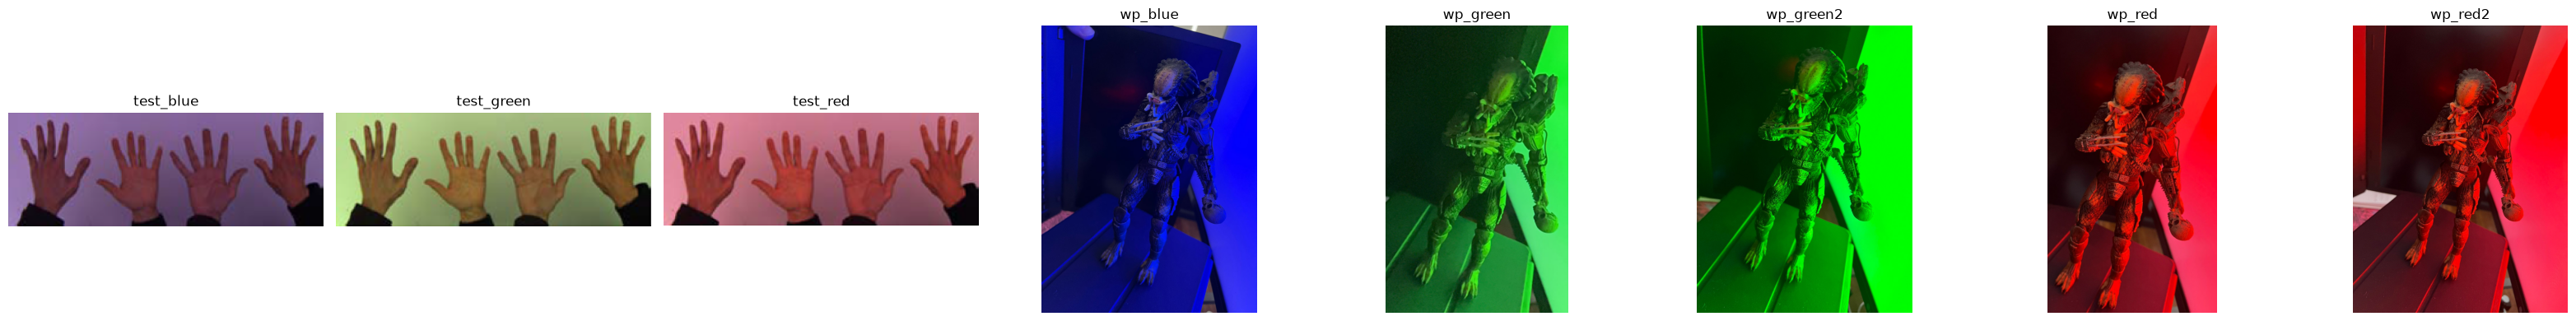

In [2]:
def load_rgb(path):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


imagenes = {p.stem: load_rgb(p) for p in sorted(IMG_DIR.iterdir())}

fig, axes = plt.subplots(1, len(imagenes), figsize=(4 * len(imagenes), 4))
for ax, (nombre, img) in zip(axes, imagenes.items()):
    ax.imshow(img)
    ax.set_title(nombre)
    ax.axis("off")
plt.tight_layout()

## Algoritmo White Patch

Idea: normalizar cada canal respecto a su valor máximo, asumiendo que el punto más brillante de la escena debería ser blanco.

$$ C'_{i} = C_{i} \cdot \frac{255}{\max(C_i)} $$

In [3]:
def white_patch(img_rgb, percentile=100):
    """
    Corrige el balance de blancos normalizando cada canal (R, G, B)
    respecto a un percentil de sus valores (percentile=100 == máximo absoluto).
    """
    img_float = img_rgb.astype(np.float32)

    # Valor de referencia por canal: percentil sobre todos los píxeles de ese canal.
    # axis=(0, 1) colapsa alto y ancho, dejando un valor por canal (shape: (3,)).
    ref = np.percentile(img_float, percentile, axis=(0, 1))

    # Evitar división por cero si algún canal es todo negro.
    ref = np.where(ref == 0, 1.0, ref)

    # Reescalar cada canal para que su referencia pase a valer 255.
    scaled = img_float * (255.0 / ref)

    # Volver al rango válido de una imagen y al tipo de dato original.
    return np.clip(scaled, 0, 255).astype(np.uint8)

## Resultados: máximo absoluto vs. percentil

Se compara el resultado con `percentile=100` (máximo) contra un percentil más bajo (98-99) y se analizan las fallas pedidas por la consigna.

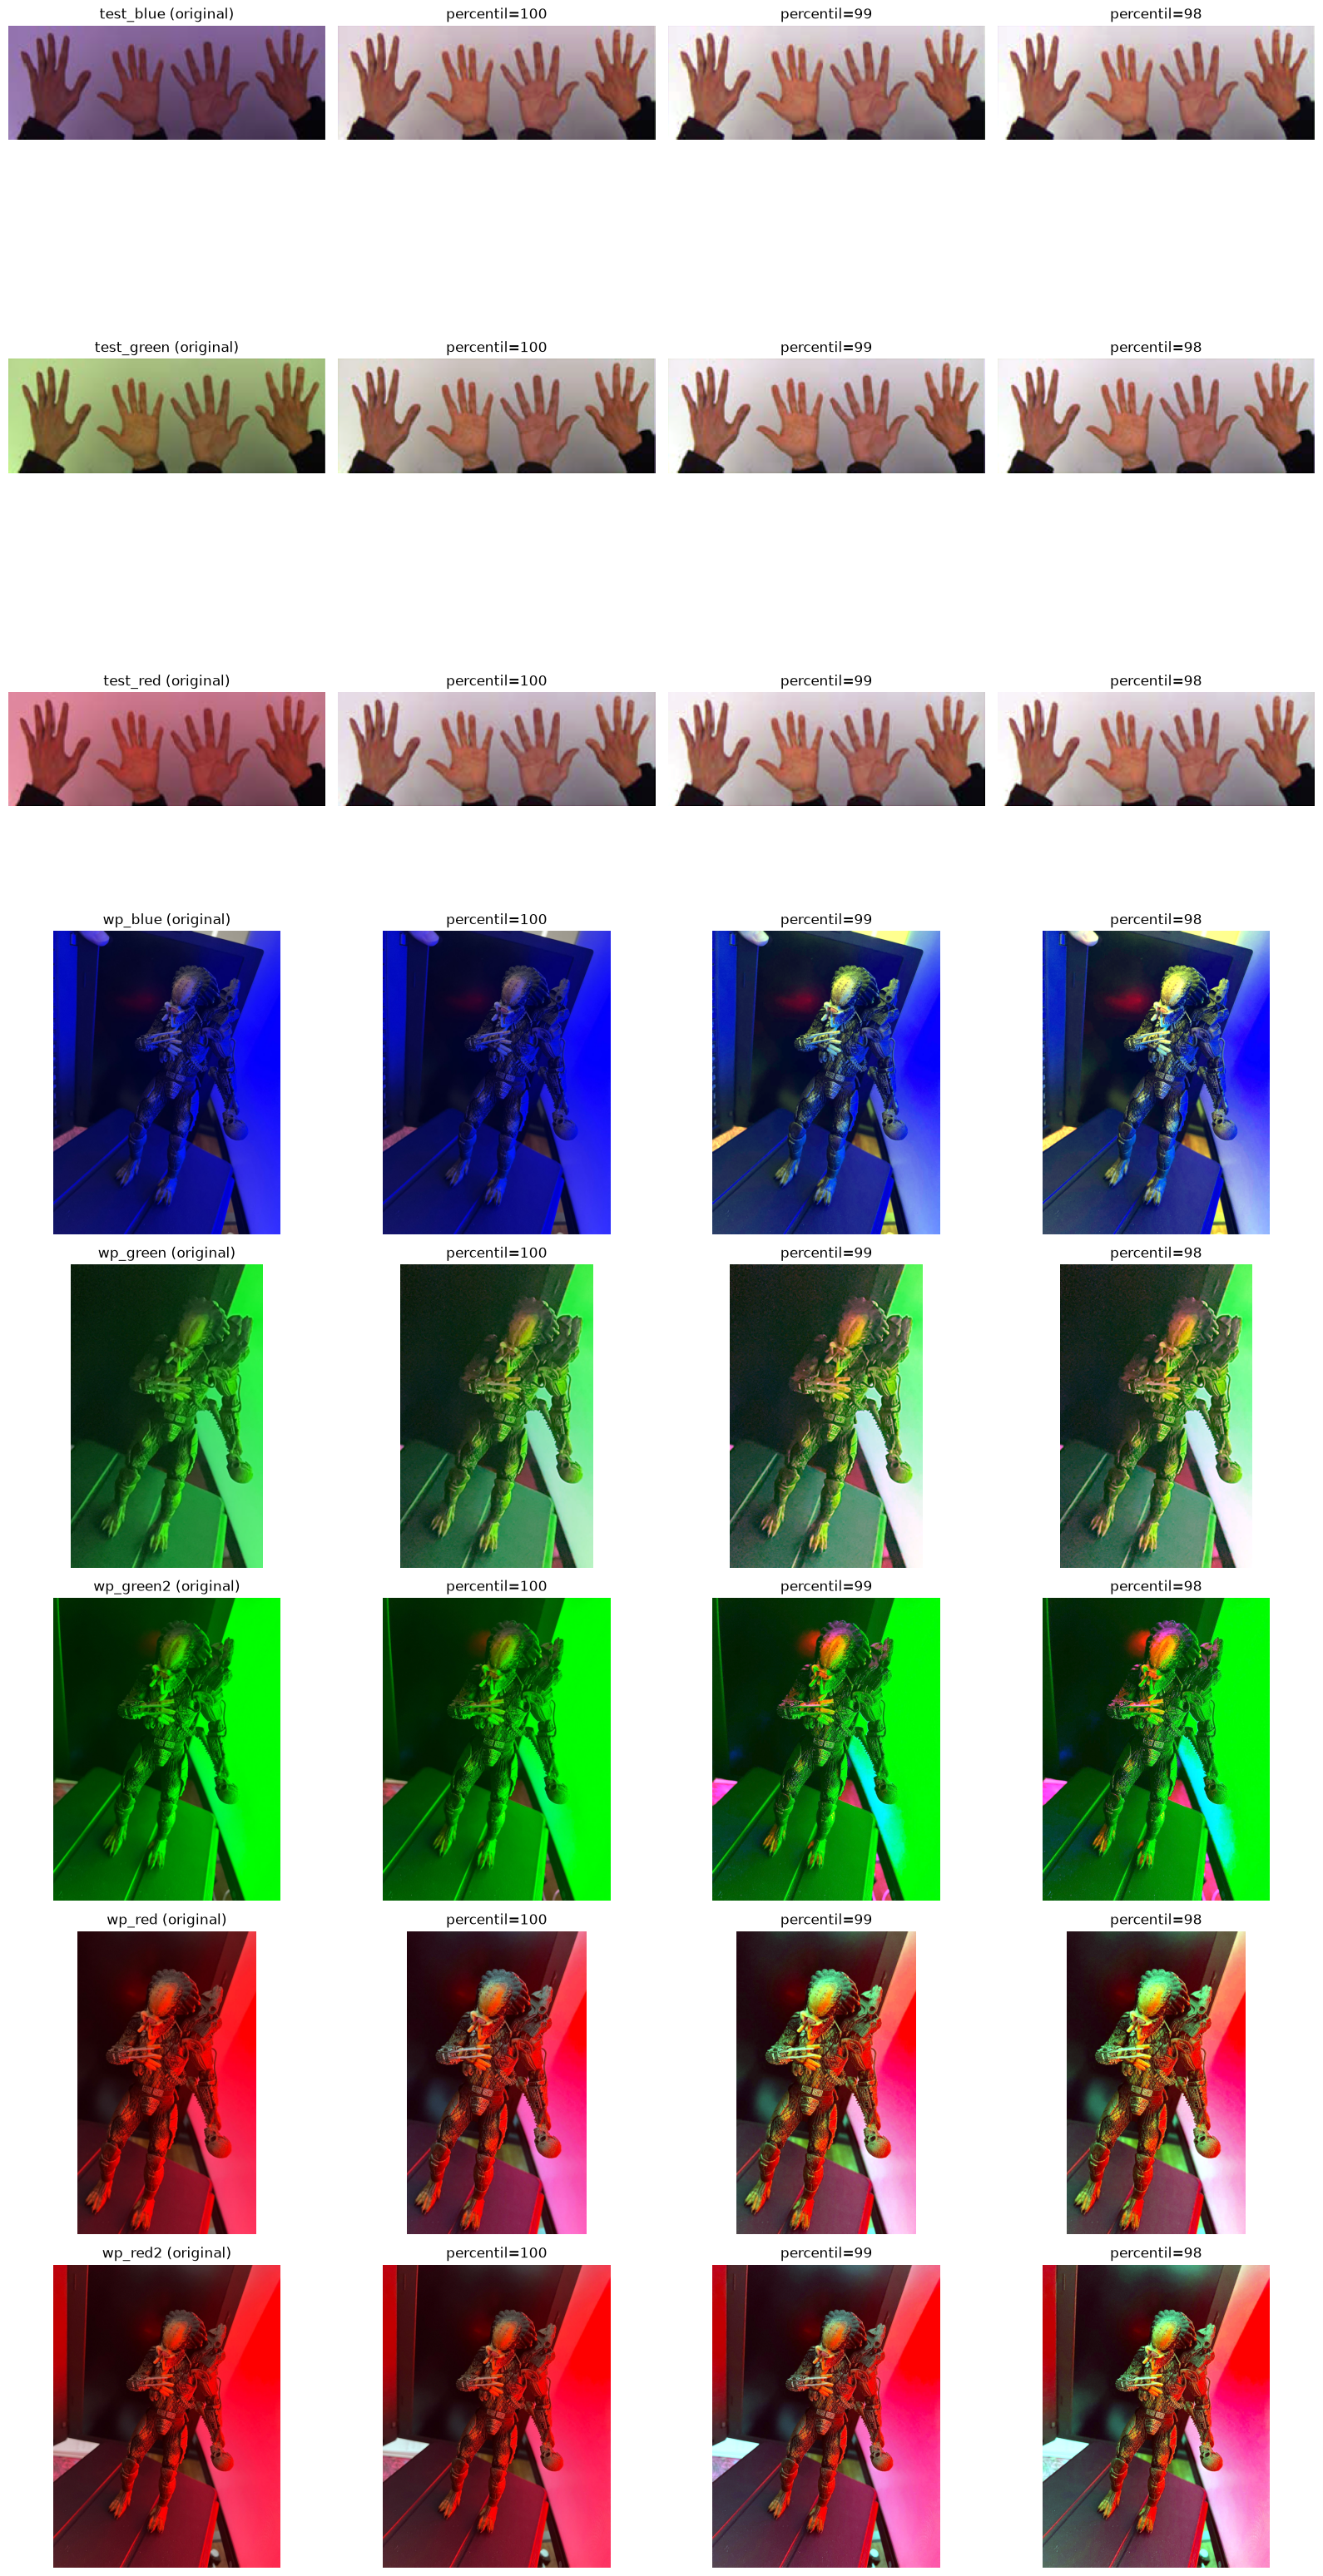

In [4]:
percentiles = [100, 99, 98]

fig, axes = plt.subplots(len(imagenes), len(percentiles) + 1,
                          figsize=(4 * (len(percentiles) + 1), 4 * len(imagenes)))

for row, (nombre, img) in enumerate(imagenes.items()):
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{nombre} (original)")
    axes[row, 0].axis("off")

    for col, p in enumerate(percentiles, start=1):
        corregida = white_patch(img, percentile=p)
        axes[row, col].imshow(corregida)
        axes[row, col].set_title(f"percentil={p}")
        axes[row, col].axis("off")

plt.tight_layout()

## Análisis de fallas

- **Con `percentile=100` (máximo absoluto):** el algoritmo depende de un único píxel de la imagen. Si ese píxel
  está saturado (255 ya de por sí, por un reflejo especular o ruido del sensor), el factor de escala
  `255/max(C)` da 1 y el algoritmo casi no corrige nada. Si en cambio ese píxel es ruido puntual muy alto en
  un solo canal, se termina "planchando" ese canal para toda la imagen, generando un tinte incorrecto
  generalizado.

- **Con percentiles 98-99:** al ignorar el 1-2% más extremo de los valores, la referencia de blanco se vuelve
  mucho más estable frente a outliers puntuales. El resultado corrige el tinte de iluminación de forma más
  consistente en toda la imagen, sin que un solo píxel "raro" arruine la normalización de un canal entero.

- **Límite que sigue existiendo:** White Patch asume que en la escena hay *al menos un objeto real que debería
  ser blanco* (o cercano a blanco) bajo luz neutra. Si la imagen no tiene ningún punto así (por ejemplo, una
  escena dominada por un solo color, sin blancos ni grises reales), la corrección va a ser incorrecta sin
  importar qué percentil uses: el algoritmo va a "inventar" un blanco a partir del objeto más claro que haya,
  aunque ese objeto no sea blanco en realidad.

### Resumen por escenario

| Escenario | Imágenes | ¿White Patch funciona? | Por qué |
|---|---|---|---|
| Hay un blanco/gris real en la escena | `test_blue`, `test_green`, `test_red` | Sí, bien | El punto más brillante es efectivamente un blanco de referencia válido, la corrección de tinte es correcta |
| Fondo dominado por un solo color saturado, sin blanco real | `wp_blue`, `wp_green`, `wp_red`, `wp_green2`, `wp_red2` | No | El máximo absoluto termina siendo parte del propio color dominante (no un blanco real), y el algoritmo "corrige" contra una referencia falsa, empeorando el tinte en vez de arreglarlo |
| Reflejo puntual o píxel de ruido saturado | Cualquiera de las anteriores, con `percentile=100` | Riesgo alto | Un solo píxel extremo define el factor de escala de todo el canal; con percentil 98-99 este riesgo baja notablemente |
| Zonas muy oscuras dentro de la imagen | Regiones de sombra en las imágenes `wp_*` | Puede amplificar ruido | El factor `255/max(C)` multiplica también los valores bajos; si `max(C)` es artificialmente bajo, se amplifica el ruido de fondo junto con la señal real |
